# Grid 4×4 Realism Benchmark — Seed 42

Corrected `sumo4x4` network. Scenarios in order:

1. **Homo** (baseline)
2. **Slow start**
3. **Hetero**
4. **Partial obs — base / pen / gauss**

RL: 200 episodes, `*_DTL.log` (TRAIN + TEST ATT). Baselines: `*_BRF.log` Final Travel Time.

**Homo baselines:** MaxPressure **173.26 s**, FixedTime **219.14 s**.

In [9]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

REPO = Path('..').resolve()
OUT = REPO / 'data' / 'output_data' / 'tsc'
COLS = ['model', 'split', 'episode', 'travel_time', 'reward', 'queue', 'delay', 'throughput']

# Canonical homo baselines (salmansserver, de13a17) — used only if BRF log not found
CANONICAL = {
    ('homo', 'maxpressure'): 173.2622,
    ('homo', 'fixedtime'): 219.14,
}

AGENTS = ['dqn', 'presslight', 'colight', 'maxpressure', 'fixedtime']
RL_AGENTS = ['dqn', 'presslight', 'colight']
AGENT_LABELS = {
    'dqn': 'DQN', 'presslight': 'PressLight', 'colight': 'CoLight',
    'maxpressure': 'MaxPressure', 'fixedtime': 'FixedTime',
}
# Tables and sections in this order
SCENARIO_ORDER = [
    ('homo', 'Homo (baseline)'),
    ('slow_start', 'Slow start'),
    ('hetero', 'Hetero'),
    ('pobs_base', 'Partial obs (base)'),
    ('pobs_pen', 'Partial obs (pen p=0.8)'),
    ('pobs_gauss', 'Partial obs (gauss σ=2)'),
]
COLORS = {
    'dqn': '#4C72B0', 'presslight': '#55A868', 'colight': '#C44E52',
    'maxpressure': '#888888', 'fixedtime': '#BBBBBB',
}


def logger_dirs(scenario, agent):
    b = OUT
    if scenario == 'homo':
        if agent in ('maxpressure', 'fixedtime'):
            return [b / f'sumo_{agent}/sumo4x4/baseline_homo/logger']
        if agent == 'colight':
            return [b / 'sumo_colight/sumo4x4/homo_4x4/logger']
        return [b / f'sumo_{agent}_sumo4x4/sumo4x4/homo_4x4/logger']
    if scenario == 'hetero':
        if agent in ('maxpressure', 'fixedtime'):
            return [b / f'sumo_{agent}_hetero/sumo4x4/baseline_hetero/logger']
        return {
            'dqn': [b / 'sumo_dqn_hetero/sumo4x4/hetero_test/logger',
                    b / 'sumo_dqn_hetero_sumo4x4/sumo4x4/hetero_4x4/logger'],
            'presslight': [b / 'sumo_presslight_hetero/sumo4x4/hetero_test/logger',
                           b / 'sumo_presslight_hetero_sumo4x4/sumo4x4/hetero_4x4/logger'],
            'colight': [b / 'sumo_colight_hetero/sumo4x4/hetero_test/logger',
                        b / 'sumo_colight_hetero/sumo4x4/hetero_4x4/logger'],
        }.get(agent, [])
    if scenario == 'slow_start':
        if agent in RL_AGENTS:
            return [b / f'sumo_{agent}_slow_start/sumo4x4/slow_start_4x4/logger']
        return [b / f'sumo_{agent}_slow_start/sumo4x4/baseline_slow_start/logger']
    if scenario.startswith('pobs_'):
        sub = scenario.replace('pobs_', '') + '_s42'
        return [b / f'sumo_{agent}_pobs/sumo4x4/{sub}/logger']
    return []


def pick_log(dirs, suffix):
    candidates = []
    for d in dirs:
        if not d.exists():
            continue
        for f in sorted(d.glob(f'*_{suffix}.log')):
            if suffix == 'DTL':
                s = sum(1 for line in open(f) if len(line.split('\t')) > 1 and line.split('\t')[1] == 'TEST')
                candidates.append((s, f.name, f))
            else:
                candidates.append((f.name, f))
    if not candidates:
        return None
    if suffix == 'DTL':
        best_score = max(c[0] for c in candidates)
        tied = [c for c in candidates if c[0] == best_score]
        return max(tied, key=lambda x: x[1])[2]
    return max(candidates, key=lambda x: x[0])[1]


def load_dtl(path):
    rows = []
    for line in open(path):
        parts = line.strip().split('\t')
        if len(parts) < 8:
            continue
        rows.append(parts[:8])
    df = pd.DataFrame(rows, columns=COLS)
    for c in ['episode', 'travel_time', 'reward', 'queue', 'delay', 'throughput']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df


def final_att_from_brf(path):
    for line in open(path):
        m = re.search(r'Final Travel Time is ([\d.]+)', line)
        if m:
            return float(m.group(1))
    return np.nan


def get_final_att(scenario, agent):
    key = (scenario, agent)
    brf = pick_log(logger_dirs(scenario, agent), 'BRF')
    if brf is not None:
        return final_att_from_brf(brf), str(brf.relative_to(REPO))
    dtl = pick_log(logger_dirs(scenario, agent), 'DTL')
    if dtl is not None:
        test = load_dtl(dtl)[lambda d: d['split'] == 'TEST']
        if len(test) >= 10:
            return float(test.iloc[-1]['travel_time']), str(dtl.relative_to(REPO))
    if key in CANONICAL:
        return CANONICAL[key], 'canonical (salman baseline)'
    return np.nan, 'MISSING'


def load_rl_frames(scenario, agent):
    dtl = pick_log(logger_dirs(scenario, agent), 'DTL')
    if dtl is None:
        return None, None, None
    df = load_dtl(dtl)
    train = df[df['split'] == 'TRAIN'].copy()
    test = df[df['split'] == 'TEST'].copy()
    if len(test) < 10:
        return None, None, None
    return train, test, str(dtl.relative_to(REPO))

## Per-scenario results (tables → bars → TRAIN/TEST curves)

Each block: summary table, bar chart, then 3 RL panels with **TRAIN** (dashed) and **TEST** (solid).

### Homo (baseline)

,Agent,Final ATT (s),Source
0,DQN,167.9,data/output_data/tsc/sumo_dqn_sumo4x4/sumo4x4/...
1,PressLight,174.4,data/output_data/tsc/sumo_presslight_sumo4x4/s...
2,CoLight,173.1,data/output_data/tsc/sumo_colight/sumo4x4/homo...
3,MaxPressure,173.3,data/output_data/tsc/sumo_maxpressure/sumo4x4/...
4,FixedTime,219.1,data/output_data/tsc/sumo_fixedtime/sumo4x4/ba...


| Agent | Final ATT (s) |
|---|---|
| DQN | **167.9** |
| PressLight | 174.4 |
| CoLight | 173.1 |
| MaxPressure | 173.3 |
| FixedTime | 219.1 |

**Best:** DQN (167.9 s)

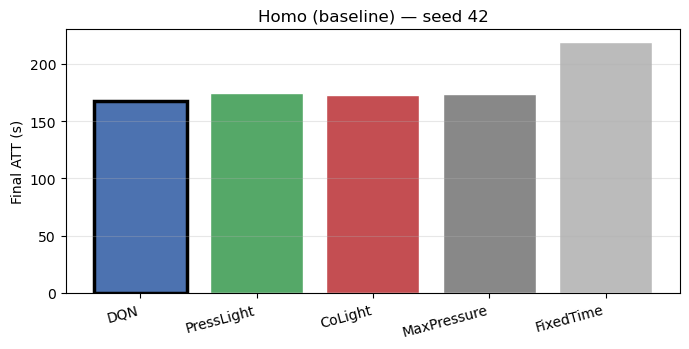

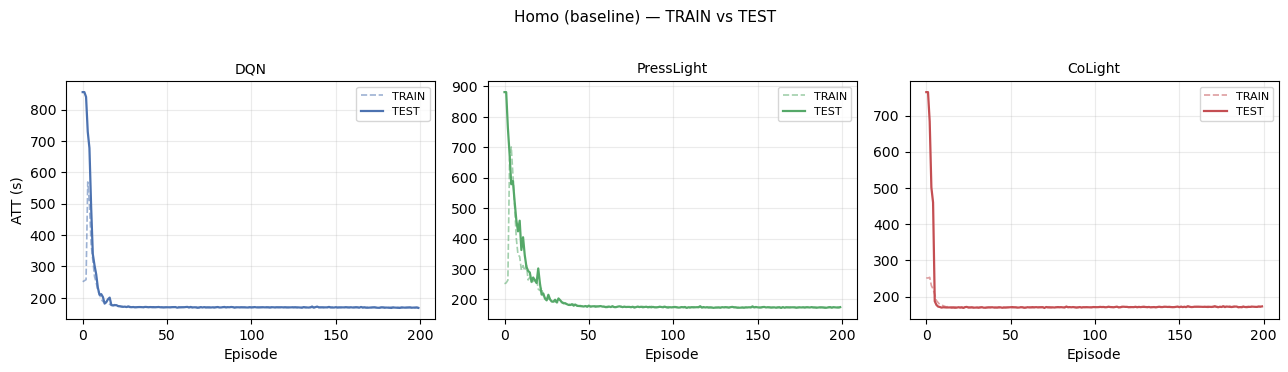

---

### Slow start

,Agent,Final ATT (s),Source
0,DQN,185.3,data/output_data/tsc/sumo_dqn_slow_start/sumo4...
1,PressLight,191.0,data/output_data/tsc/sumo_presslight_slow_star...
2,CoLight,190.4,data/output_data/tsc/sumo_colight_slow_start/s...
3,MaxPressure,186.0,data/output_data/tsc/sumo_maxpressure_slow_sta...
4,FixedTime,243.7,data/output_data/tsc/sumo_fixedtime_slow_start...


| Agent | Final ATT (s) |
|---|---|
| DQN | **185.3** |
| PressLight | 191.0 |
| CoLight | 190.4 |
| MaxPressure | 186.0 |
| FixedTime | 243.7 |

**Best:** DQN (185.3 s)

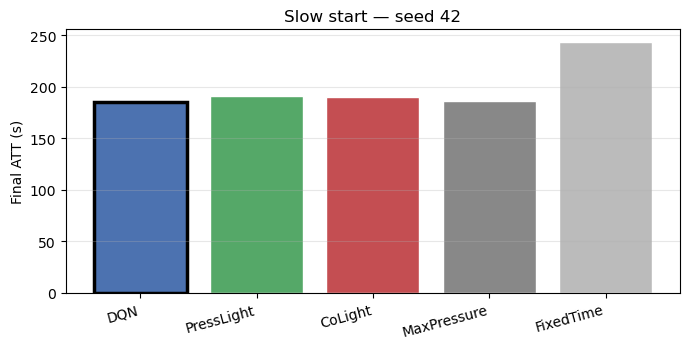

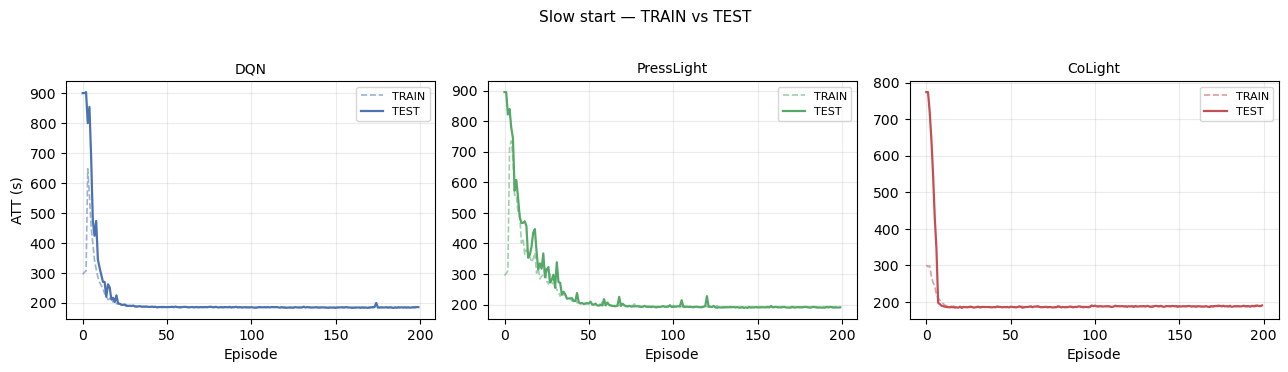

---

### Hetero

,Agent,Final ATT (s),Source
0,DQN,184.0,data/output_data/tsc/sumo_dqn_hetero/sumo4x4/h...
1,PressLight,189.3,data/output_data/tsc/sumo_presslight_hetero/su...
2,CoLight,189.1,data/output_data/tsc/sumo_colight_hetero/sumo4...
3,MaxPressure,189.3,data/output_data/tsc/sumo_maxpressure_hetero/s...
4,FixedTime,240.4,data/output_data/tsc/sumo_fixedtime_hetero/sum...


| Agent | Final ATT (s) |
|---|---|
| DQN | **184.0** |
| PressLight | 189.3 |
| CoLight | 189.1 |
| MaxPressure | 189.3 |
| FixedTime | 240.4 |

**Best:** DQN (184.0 s)

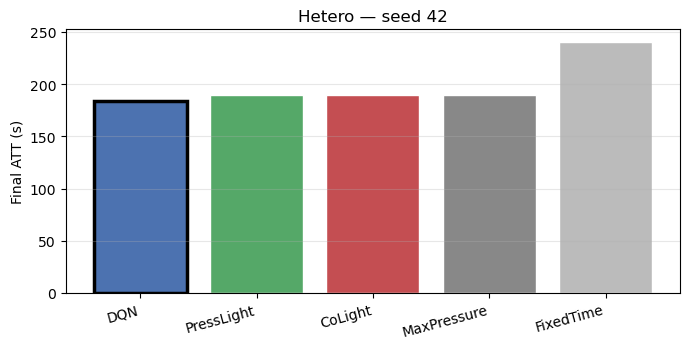

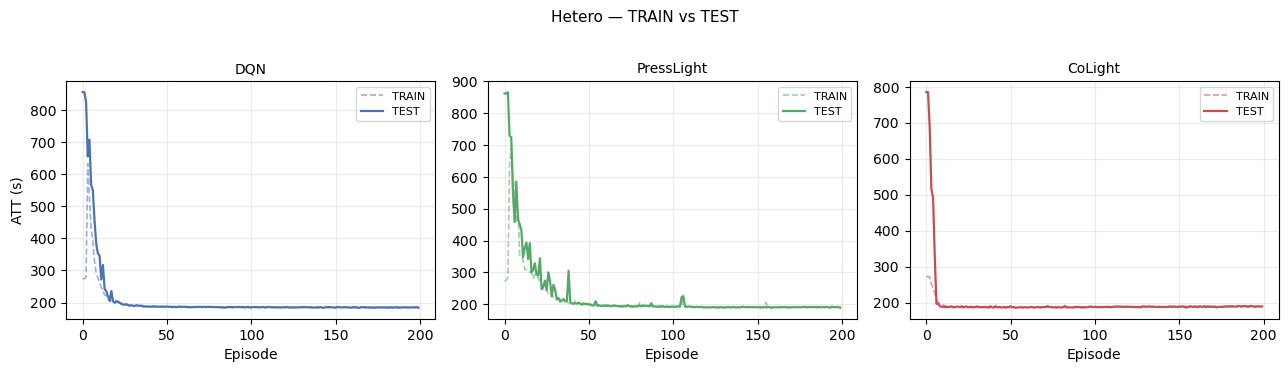

---

### Partial obs (base)

,Agent,Final ATT (s),Source
0,DQN,171.8,data/output_data/tsc/sumo_dqn_pobs/sumo4x4/bas...
1,PressLight,177.6,data/output_data/tsc/sumo_presslight_pobs/sumo...
2,CoLight,174.7,data/output_data/tsc/sumo_colight_pobs/sumo4x4...
3,MaxPressure,174.9,data/output_data/tsc/sumo_maxpressure_pobs/sum...
4,FixedTime,219.7,data/output_data/tsc/sumo_fixedtime_pobs/sumo4...


| Agent | Final ATT (s) |
|---|---|
| DQN | **171.8** |
| PressLight | 177.6 |
| CoLight | 174.7 |
| MaxPressure | 174.9 |
| FixedTime | 219.7 |

**Best:** DQN (171.8 s)

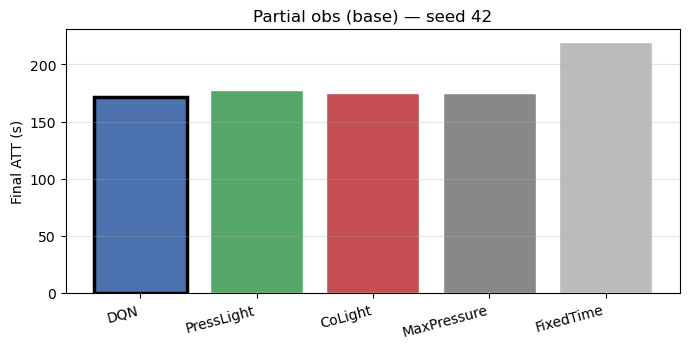

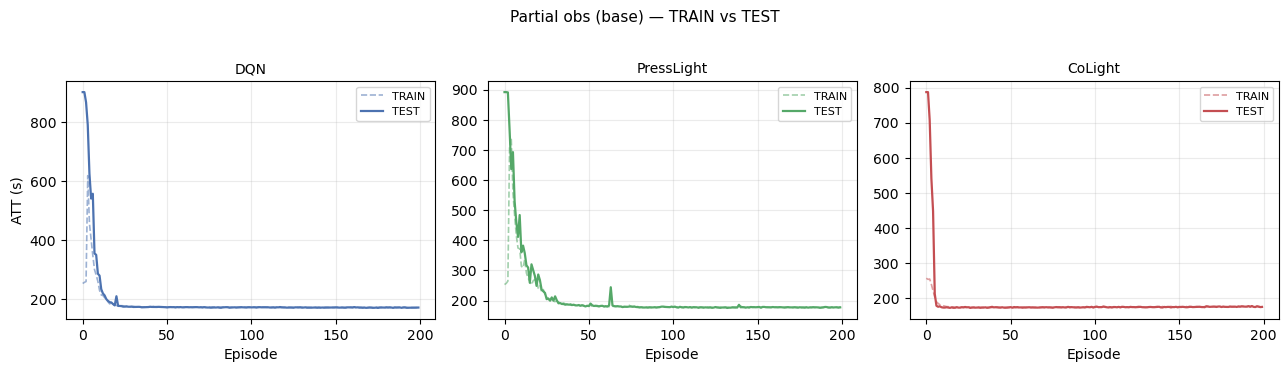

---

### Partial obs (pen p=0.8)

,Agent,Final ATT (s),Source
0,DQN,183.3,data/output_data/tsc/sumo_dqn_pobs/sumo4x4/pen...
1,PressLight,185.8,data/output_data/tsc/sumo_presslight_pobs/sumo...
2,CoLight,185.1,data/output_data/tsc/sumo_colight_pobs/sumo4x4...
3,MaxPressure,185.3,data/output_data/tsc/sumo_maxpressure_pobs/sum...
4,FixedTime,219.7,data/output_data/tsc/sumo_fixedtime_pobs/sumo4...


| Agent | Final ATT (s) |
|---|---|
| DQN | **183.3** |
| PressLight | 185.8 |
| CoLight | 185.1 |
| MaxPressure | 185.3 |
| FixedTime | 219.7 |

**Best:** DQN (183.3 s)

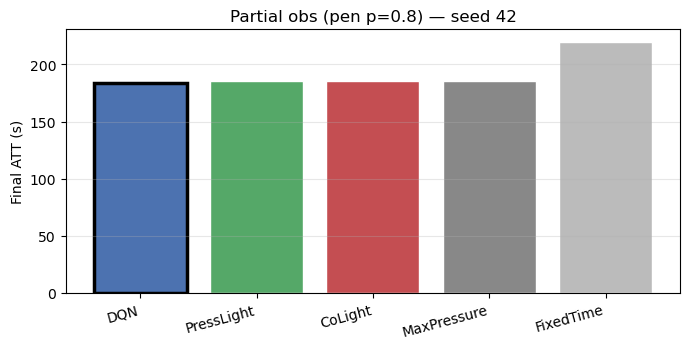

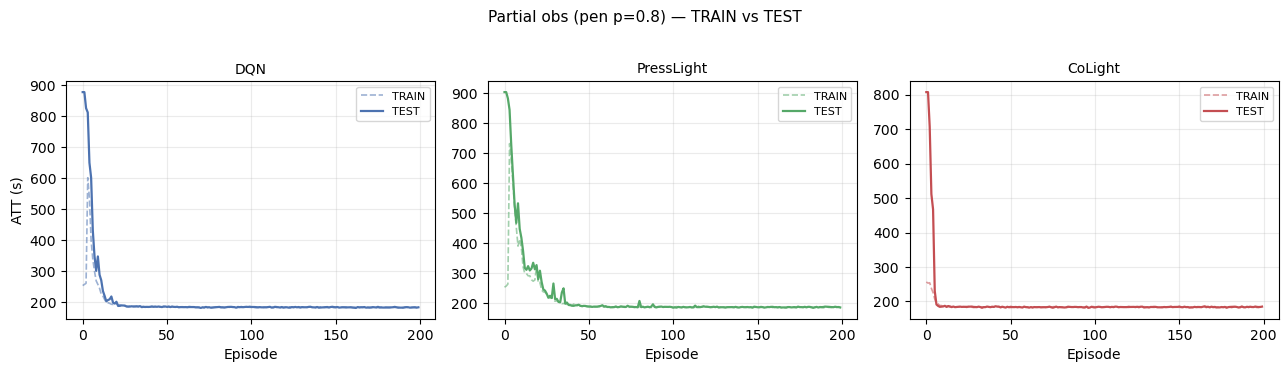

---

### Partial obs (gauss σ=2)

,Agent,Final ATT (s),Source
0,DQN,231.8,data/output_data/tsc/sumo_dqn_pobs/sumo4x4/gau...
1,PressLight,201.9,data/output_data/tsc/sumo_presslight_pobs/sumo...
2,CoLight,312.2,data/output_data/tsc/sumo_colight_pobs/sumo4x4...
3,MaxPressure,200.9,data/output_data/tsc/sumo_maxpressure_pobs/sum...
4,FixedTime,219.7,data/output_data/tsc/sumo_fixedtime_pobs/sumo4...


| Agent | Final ATT (s) |
|---|---|
| DQN | 231.8 |
| PressLight | 201.9 |
| CoLight | 312.2 |
| MaxPressure | **200.9** |
| FixedTime | 219.7 |

**Best:** MaxPressure (200.9 s)

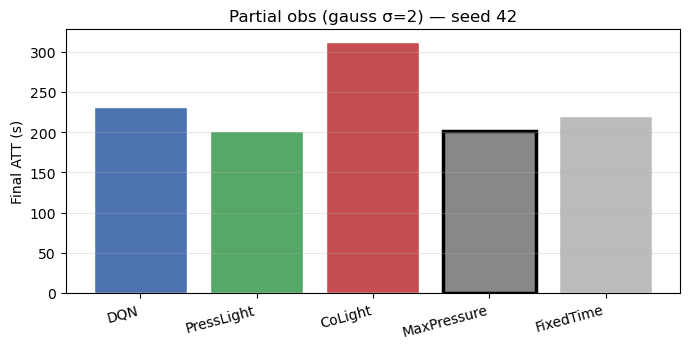

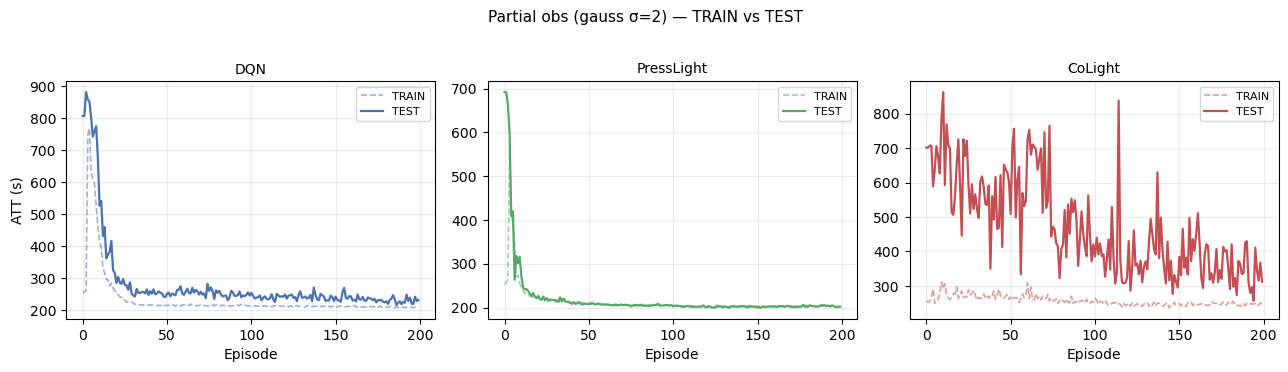

---

In [11]:
def scenario_table(scenario_key, title):
    rows = []
    best_v, best_a = np.inf, None
    for agent in AGENTS:
        att, src = get_final_att(scenario_key, agent)
        rows.append({
            'Agent': AGENT_LABELS[agent],
            'Final ATT (s)': round(att, 1) if not np.isnan(att) else None,
            'Source': src,
        })
        if not np.isnan(att) and att < best_v:
            best_v, best_a = att, AGENT_LABELS[agent]
    df = pd.DataFrame(rows)
    display(Markdown(f'### {title}'))
    display(df)
    md = ['| Agent | Final ATT (s) |', '|---|---|']
    for _, r in df.iterrows():
        v = r['Final ATT (s)']
        cell = f'**{v:.1f}**' if v is not None and abs(v - best_v) < 0.05 else (f'{v:.1f}' if v is not None else '—')
        md.append(f"| {r['Agent']} | {cell} |")
    md.append(f'\n**Best:** {best_a} ({best_v:.1f} s)')
    display(Markdown('\n'.join(md)))
    return best_v, best_a


def scenario_bars(scenario_key, title):
    vals, labels, cols = [], [], []
    for agent in AGENTS:
        att, _ = get_final_att(scenario_key, agent)
        if np.isnan(att):
            continue
        vals.append(att)
        labels.append(AGENT_LABELS[agent])
        cols.append(COLORS[agent])
    if not vals:
        return
    best = min(vals)
    fig, ax = plt.subplots(figsize=(7, 3.6))
    bars = ax.bar(labels, vals, color=cols, edgecolor='white')
    for b, v in zip(bars, vals):
        if abs(v - best) < 0.05:
            b.set_edgecolor('black')
            b.set_linewidth(2.5)
    ax.set_ylabel('Final ATT (s)')
    ax.set_title(f'{title} — seed 42')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()


def scenario_curves(scenario_key, title):
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)
    for j, agent in enumerate(RL_AGENTS):
        ax = axes[j]
        train, test, src = load_rl_frames(scenario_key, agent)
        if train is not None:
            ax.plot(train['episode'], train['travel_time'], '--', color=COLORS[agent],
                    alpha=0.55, lw=1.2, label='TRAIN')
            ax.plot(test['episode'], test['travel_time'], '-', color=COLORS[agent],
                    lw=1.6, label='TEST')
            ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, 'NO DTL', ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.set_title(AGENT_LABELS[agent], fontsize=10)
        ax.set_xlabel('Episode')
        if j == 0:
            ax.set_ylabel('ATT (s)')
        ax.grid(True, alpha=0.25)
    fig.suptitle(f'{title} — TRAIN vs TEST', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()


for sk, title in SCENARIO_ORDER:
    scenario_table(sk, title)
    scenario_bars(sk, title)
    scenario_curves(sk, title)
    display(Markdown('---'))

## Cross-scenario summary (all toggles)

In [13]:
summary_rows = []
for sk, title in SCENARIO_ORDER:
    row = {'Scenario': title}
    best_v, best_a = np.inf, None
    for agent in AGENTS:
        att, _ = get_final_att(sk, agent)
        lbl = AGENT_LABELS[agent]
        row[lbl] = round(att, 1) if not np.isnan(att) else None
        if not np.isnan(att) and att < best_v:
            best_v, best_a = att, lbl
    row['Best'] = f'{best_a} ({best_v:.1f}s)' if best_a else None
    summary_rows.append(row)
summary = pd.DataFrame(summary_rows)
display(summary)

md_lines = ['| Scenario | ' + ' | '.join(AGENT_LABELS[a] for a in AGENTS) + ' | Best |',
            '|' + '---|' * (len(AGENTS) + 2)]
for _, r in summary.iterrows():
    best_v = float(r['Best'].split('(')[1].rstrip('s)')) if r['Best'] else None
    cells = [r['Scenario']]
    for a in AGENTS:
        v = r[AGENT_LABELS[a]]
        if v is None:
            cells.append('—')
        else:
            cells.append(f'**{v:.1f}**' if best_v and abs(v - best_v) < 0.05 else f'{v:.1f}')
    cells.append(f"**{r['Best']}**" if r['Best'] else '—')
    md_lines.append('| ' + ' | '.join(cells) + ' |')
display(Markdown('\n'.join(md_lines)))

,Scenario,DQN,PressLight,CoLight,MaxPressure,FixedTime,Best
0,Homo (baseline),167.9,174.4,173.1,173.3,219.1,DQN (167.9s)
1,Slow start,185.3,191.0,190.4,186.0,243.7,DQN (185.3s)
2,Hetero,184.0,189.3,189.1,189.3,240.4,DQN (184.0s)
3,Partial obs (base),171.8,177.6,174.7,174.9,219.7,DQN (171.8s)
4,Partial obs (pen p=0.8),183.3,185.8,185.1,185.3,219.7,DQN (183.3s)
5,Partial obs (gauss σ=2),231.8,201.9,312.2,200.9,219.7,MaxPressure (200.9s)


| Scenario | DQN | PressLight | CoLight | MaxPressure | FixedTime | Best |
|---|---|---|---|---|---|---|
| Homo (baseline) | **167.9** | 174.4 | 173.1 | 173.3 | 219.1 | **DQN (167.9s)** |
| Slow start | **185.3** | 191.0 | 190.4 | 186.0 | 243.7 | **DQN (185.3s)** |
| Hetero | **184.0** | 189.3 | 189.1 | 189.3 | 240.4 | **DQN (184.0s)** |
| Partial obs (base) | **171.8** | 177.6 | 174.7 | 174.9 | 219.7 | **DQN (171.8s)** |
| Partial obs (pen p=0.8) | **183.3** | 185.8 | 185.1 | 185.3 | 219.7 | **DQN (183.3s)** |
| Partial obs (gauss σ=2) | 231.8 | 201.9 | 312.2 | **200.9** | 219.7 | **MaxPressure (200.9s)** |

## Realism penalty vs homo baseline (RL agents)

,Scenario,Agent,Homo ATT,Toggle ATT,Δ vs homo (s)
0,Slow start,DQN,167.9,185.3,17.4
1,Slow start,PressLight,174.4,191.0,16.7
2,Slow start,CoLight,173.1,190.4,17.4
3,Hetero,DQN,167.9,184.0,16.1
4,Hetero,PressLight,174.4,189.3,14.9
5,Hetero,CoLight,173.1,189.1,16.1
6,Partial obs (base),DQN,167.9,171.8,3.9
7,Partial obs (base),PressLight,174.4,177.6,3.2
8,Partial obs (base),CoLight,173.1,174.7,1.6
9,Partial obs (pen p=0.8),DQN,167.9,183.3,15.4


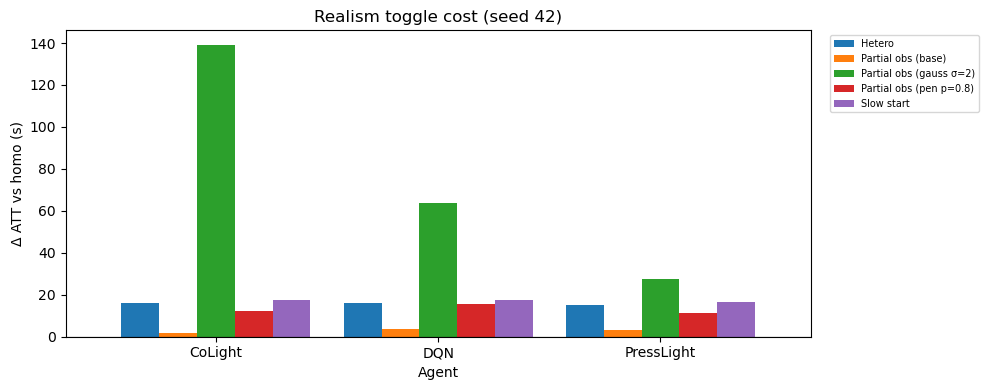

In [14]:
homo_ref = {a: get_final_att('homo', a)[0] for a in RL_AGENTS}
delta_rows = []
for sk, title in SCENARIO_ORDER[1:]:
    for agent in RL_AGENTS:
        att, _ = get_final_att(sk, agent)
        base = homo_ref[agent]
        delta_rows.append({
            'Scenario': title,
            'Agent': AGENT_LABELS[agent],
            'Homo ATT': round(base, 1),
            'Toggle ATT': round(att, 1) if not np.isnan(att) else None,
            'Δ vs homo (s)': round(att - base, 1) if not (np.isnan(att) or np.isnan(base)) else None,
        })
delta_df = pd.DataFrame(delta_rows)
display(delta_df)

fig, ax = plt.subplots(figsize=(10, 4))
pivot = delta_df.pivot(index='Agent', columns='Scenario', values='Δ vs homo (s)')
pivot.plot(kind='bar', ax=ax, rot=0, width=0.85)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('Δ ATT vs homo (s)')
ax.set_title('Realism toggle cost (seed 42)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

## Summary

- **Homo baseline:** MaxPressure **173.26 s**, FixedTime **219.14 s** (salman canonical; used when `baseline_homo` BRF not committed).
- **Slow-start / pobs baselines** come from committed `*_BRF.log` only — no duplicate hardcoded values.
- **RL curves** show TRAIN (dashed) and TEST (solid) per episode, matching other experiment notebooks.
- **FixedTime** is worst on every toggle. RL methods cluster near MaxPressure on homo/hetero/slow-start.
- **Gaussian partial obs** hits CoLight hardest; penetration p=0.8 is a moderate ~10–15 s penalty vs homo.